In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as Thien

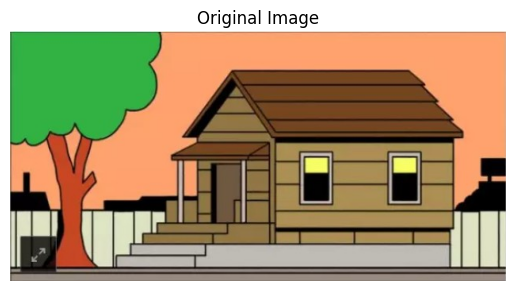

In [ ]:
img = cv2.imread('hinh1.jpg')

Thien.imshow(img[:,:,::-1])
Thien.title("Original Image")
Thien.axis("off")
Thien.show()

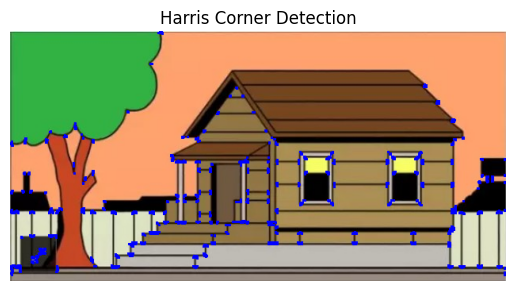

In [ ]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gray = np.float32(img_gray)

dst = cv2.cornerHarris(img_gray,2,3,0.04)

dst = cv2.dilate(dst,None)

img_harris = img.copy()
img_harris[dst>0.01*dst.max()] = [255,0,0]

Thien.imshow(img_harris[:,:,::-1])
Thien.title("Harris Corner Detection")
Thien.axis("off")
Thien.show()

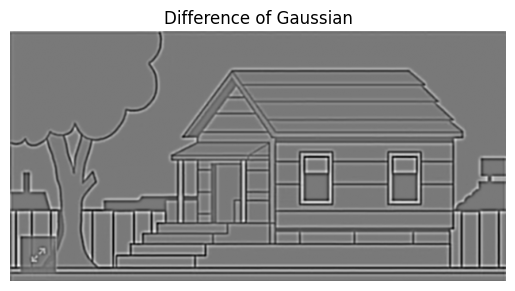

In [ ]:
blur1 = cv2.GaussianBlur(img_gray,(5,5),1)
blur2 = cv2.GaussianBlur(img_gray,(9,9),2)

dog = blur1 - blur2

Thien.imshow(dog, cmap='gray')
Thien.title("Difference of Gaussian")
Thien.axis("off")
Thien.show()

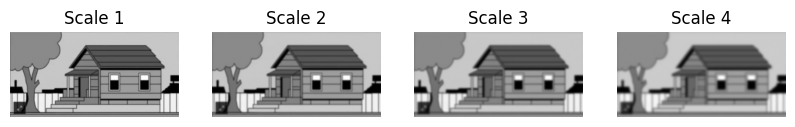

In [ ]:
scales = [1,2,3,4]
responses = []

for s in scales:
    blur = cv2.GaussianBlur(img_gray,(0,0),s)
    responses.append(blur)

Thien.figure(figsize=(10,5))

for i in range(len(scales)):
    Thien.subplot(1,4,i+1)
    Thien.imshow(responses[i], cmap='gray')
    Thien.title("Scale "+str(scales[i]))
    Thien.axis("off")

Thien.show()

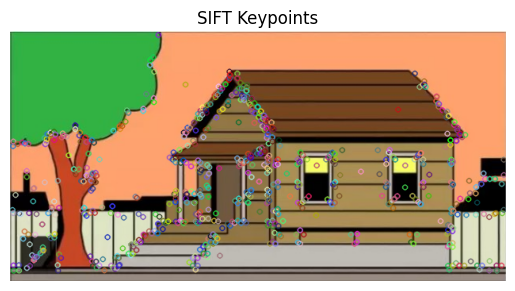

In [ ]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(img_gray, None)

img_sift = cv2.drawKeypoints(img, kp, None)

Thien.imshow(img_sift[:,:,::-1])
Thien.title("SIFT Keypoints")
Thien.axis("off")
Thien.show()

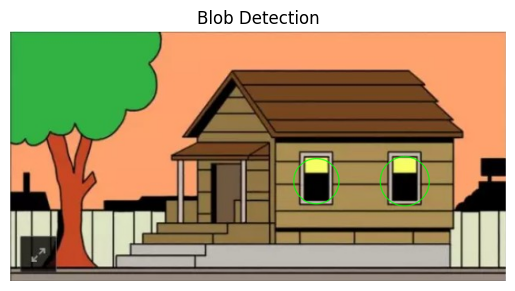

In [ ]:
blob = cv2.SimpleBlobDetector_create()

keypoints = blob.detect(img_gray)

img_blob = cv2.drawKeypoints(img,keypoints,None,(0,255,0),
                             cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

Thien.imshow(img_blob[:,:,::-1])
Thien.title("Blob Detection")
Thien.axis("off")
Thien.show()

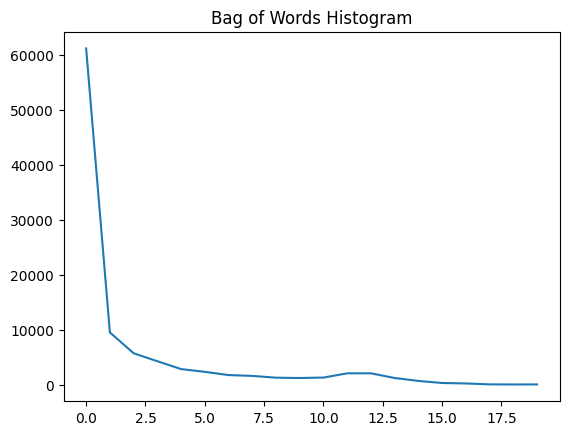

In [ ]:
sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(img_gray,None)

hist = np.histogram(des, bins=20)

Thien.plot(hist[0])
Thien.title("Bag of Words Histogram")
Thien.show()

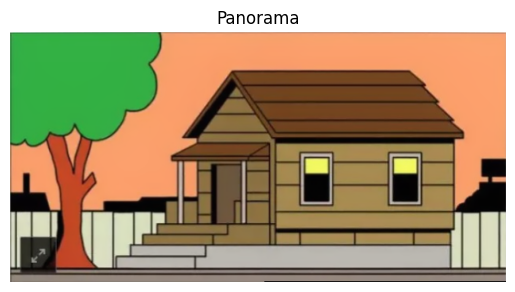

In [ ]:
img = cv2.imread("hinh1.jpg")

h, w = img.shape[:2]

img1 = img[:, :int(w*0.7)]
img2 = img[:, int(w*0.3):]

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img1, img2])

if status == 0:
    Thien.imshow(pano[:,:,::-1])
    Thien.title("Panorama")
    Thien.axis("off")
    Thien.show()
else:
    print("Stitching failed")

In [ ]:
hist1 = cv2.calcHist([img],[0],None,[256],[0,256])
hist2 = cv2.calcHist([img2],[0],None,[256],[0,256])

score = cv2.compareHist(hist1,hist2,cv2.HISTCMP_CORREL)

print("Similarity Score:", score)

Similarity Score: 0.8552120196458384
